# Neuro-Symbolic PPM — Benchmark Analysis

### Does *clean* symbolic temporal knowledge keep a neural next-activity model conformant under **label noise**, across **three event logs**?

This notebook reads a single results file, `runs/benchmark_corruption.csv`, produced by
`nspm.pipeline.benchmark.run_corruption_grid`, and turns it into the figures the thesis
argues from. It does **not** train anything — it is the *validation / reporting* stage of
the PPM pipeline `event log → prefix log → encoding → learning → validation`
(Di Francescomarino, Donadello & Maggi, *Predictive Process Monitoring*, Springer 2026, Ch. 2 & 6).

**The experimental grid.** The symbolic layer — an empirical **directly-follows DFA** and
mined **LTLf precedence** rules — is built **once on the full clean training set** and held
fixed. Only the *neural* training labels are corrupted by a `noise_level` fraction. Each cell
trains a model and evaluates on a **clean, fixed** test set, so every row is comparable.

**The variants** (T-LEAF: Xie, Zhou & Soh, *Embedding Symbolic Temporal Knowledge into Deep
Sequential Models*, arXiv:2101.11981):

| variant | what it is | conformance mechanism |
|---|---|---|
| `baseline` | plain next-activity model | none |
| `baseline_mask` | same weights, DFA-forbidden classes removed at inference | hard masking (§ post-hoc) |
| `checker` | trained with the differentiable **forbidden-mass logic loss** | soft penalty (T-LEAF §4 logic loss) |
| `embedder` | trained with the **T-LEAF embedding logic loss** `‖q(A) − q(w_pred)‖²` | soft, graph-embedding (T-LEAF §3–4) |

**The questions this notebook answers**

1. **Datasets** — how differently hard are the three logs?
2. **Noise** — does predictive quality degrade as labels are corrupted?
3. **Does T-LEAF work?** — does the symbolic layer keep predictions *process-conformant* under noise?
4. **Trade-off** — what accuracy does the logic loss cost for that conformance?
5. **Correlation** — which design axes and outcomes move together?

## 0. Setup — load the results table

We make `nspm` importable from anywhere under the repo, load the tidy CSV, and print a
one-line description of the grid. Every plotting function lives in
`src/nspm/visualization/benchmark_plots.py` and is *called* from here — the notebook stays a
narrated orchestration, the reusable logic stays in the codebase.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import pandas as pd

# Make `nspm` importable from anywhere under the repository.
ROOT = Path.cwd()
while not (ROOT / "src" / "nspm").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from nspm.visualization import benchmark_plots as bp

RESULTS_CSV = ROOT / "runs" / "benchmark_corruption.csv"
FIG_DIR = ROOT / "runs" / "figures" / "benchmark"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RESULTS_CSV)
summary = bp.summarize_benchmark(df)
print(f"rows           : {summary['n_rows']}")
print(f"datasets       : {summary['datasets']}")
print(f"architectures  : {summary['architectures']}")
print(f"variants       : {summary['variants']}")
print(f"noise levels   : {summary['noise_levels']}")
print(f"seeds          : {summary['seeds']}")
df.head()

rows           : 384
datasets       : ['BPIC_2013_incidents', 'Sepsis_Case', 'BPIC_2020_DomesticDeclarations']
architectures  : ['gru', 'lstm']
variants       : ['baseline', 'baseline_mask', 'checker', 'embedder']
noise levels   : [0.0, 0.1, 0.25, 0.4]
seeds          : [42]


,dataset,architecture,variant,train_fraction,noise_level,seed,n_train_cases,n_train_examples,n_train_corrupted,n_constraints,...,train_runtime_s,precedence_violation_rate,loss,accuracy,macro_f1,macro_precision,macro_recall,top_k_accuracy,violation_rate,forbidden_mass
0,BPIC_2013_incidents,gru,baseline,1.0,0.0,42,5287,45689,0,1,...,32.37,0.0,0.625756,0.718171,0.574555,0.678273,0.545327,1.0,0.0,0.000103
1,BPIC_2013_incidents,gru,baseline_mask,1.0,0.0,42,5287,45689,0,1,...,32.37,0.0,0.625756,0.718171,0.574555,0.678273,0.545327,1.0,0.0,0.000000
2,BPIC_2013_incidents,gru,checker,1.0,0.0,42,5287,45689,0,1,...,80.28,0.0,0.621484,0.720334,0.544456,0.621061,0.551396,1.0,0.0,0.000012
3,BPIC_2013_incidents,gru,embedder,1.0,0.0,42,5287,45689,0,1,...,796.96,0.0,0.620957,0.721570,0.596847,0.688761,0.567212,1.0,0.0,0.000025
4,BPIC_2013_incidents,gru,baseline,1.0,0.1,42,5287,45689,4569,1,...,36.31,0.0,0.677751,0.714462,0.568346,0.661666,0.541571,1.0,0.0,0.021870


> **Note on scope.** This file is the *corruption* sweep: it varies `noise_level` on the
> **full** training set. Data-scarcity (`train_fraction`) and the `embedder` branch are run
> by a separate grid; the cells below detect whichever columns/variants are present and adapt,
> so re-running this notebook on a richer CSV (with `embedder` rows or a `train_fraction`
> column) lights up the extra plots automatically.

## 1. How hard is each dataset? (clean baseline)

Before any noise, how well does a plain model predict the next activity on each log? We take
the `noise_level == 0`, `baseline` rows (mean over GRU/LSTM). The bars also annotate the **DFA
size** and **prefix count** that contextualise the difficulty: a log with a small, tight DFA
and high baseline accuracy (BPIC-2020) leaves little room for a logic loss to help; a hard,
imbalanced log (Sepsis) is where conformance pressure matters most.

*Source: PPM book Ch. 3 (control-flow / variants) and Ch. 6 (evaluation metrics).*

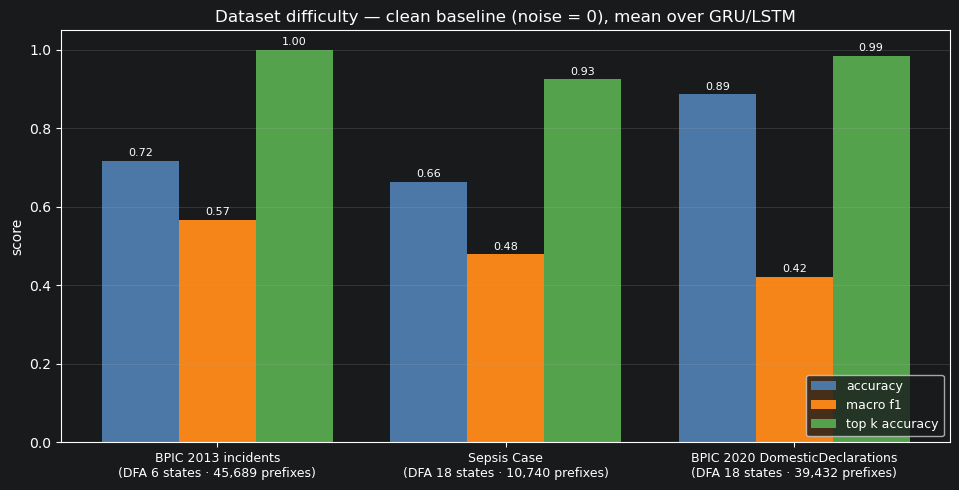

In [2]:
bp.plot_dataset_overview(df, path=FIG_DIR / "01_dataset_overview.png");

## 2. Does predictive quality degrade under label noise?

Each facet is one dataset; `x` is the fraction of training targets corrupted to a random DFA
activity; one line per variant (mean over architectures). If the lines stay roughly flat, the
model is robust to noisy supervision; if they fall, corruption is biting. Watch whether the
logic variants (`checker`, and `embedder` if present) degrade **slower** than the bare
`baseline` — a soft constraint can act as a regulariser against label noise.

*T-LEAF arXiv:2101.11981 §5 (robustness of logic-guided training).*

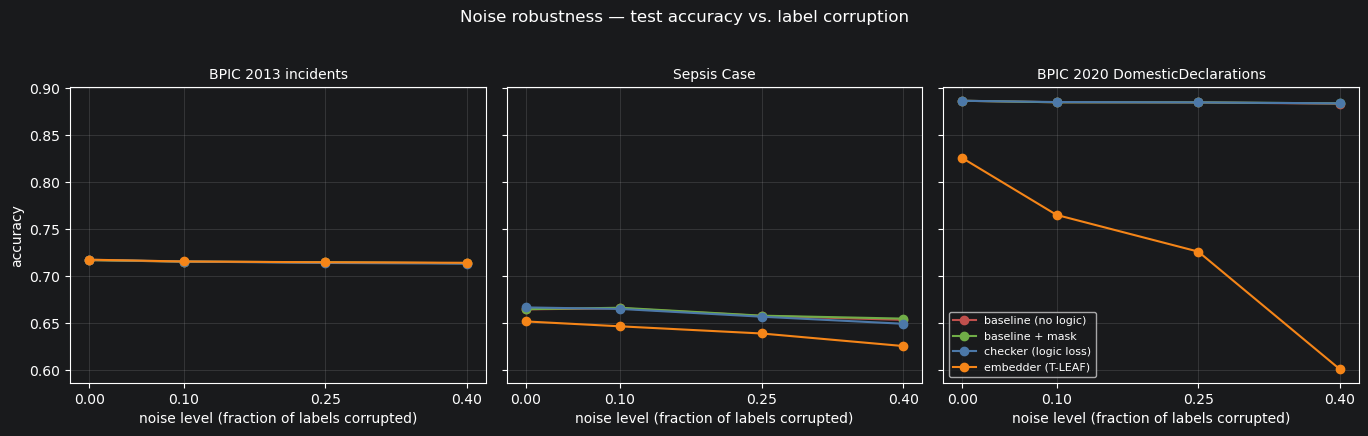

In [3]:
bp.plot_noise_robustness(df, metric="accuracy", path=FIG_DIR / "02_noise_accuracy.png");

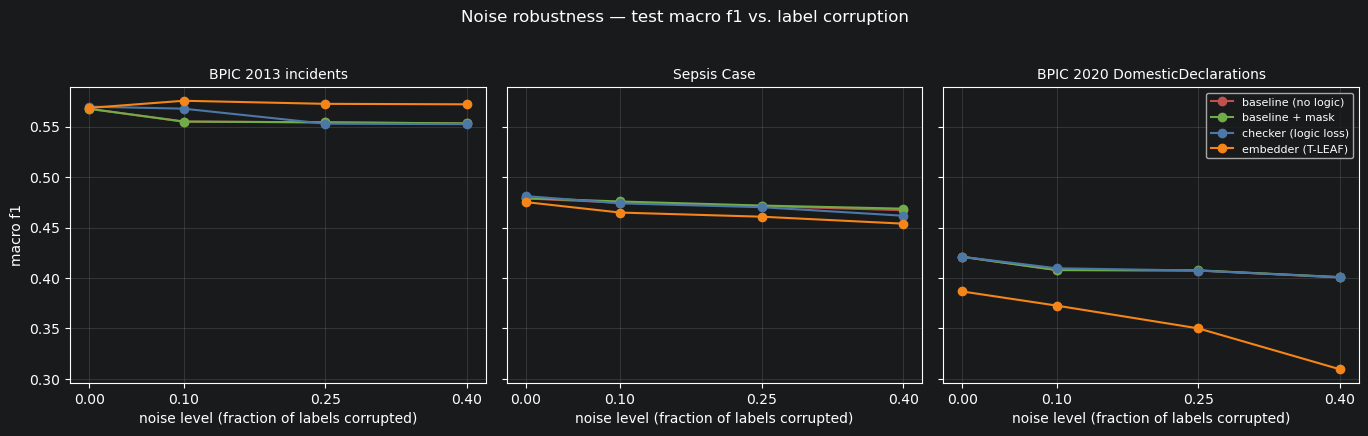

In [4]:
# Macro-F1 is the fairer lens on the imbalanced logs (Sepsis especially).
bp.plot_noise_robustness(df, metric="macro_f1", path=FIG_DIR / "02_noise_macro_f1.png");

## 3. Does the symbolic layer keep predictions *conformant*? — the core T-LEAF result

`forbidden_mass` is the probability the model places on next activities the DFA **forbids**
(lower = more process-conformant). This is the metric the thesis lives or dies on. Expected
story per facet:

- **`baseline`** (red) — forbidden mass **rises with noise**: a model trained on corrupted
  labels increasingly predicts illegal continuations.
- **`baseline_mask`** (green) — sits at **exactly 0**: forbidden classes are zeroed at
  inference. Free conformance, but purely post-hoc.
- **`checker`** (blue) — the **soft logic loss** holds forbidden mass *well below* the
  baseline at every noise level, *without* hard masking — the headline claim that the
  differentiable penalty earns its keep.
- **`embedder`** (orange, if present) — the T-LEAF embedding loss, same idea via graph
  embeddings.

*T-LEAF §4 (logic loss); PPM book Ch. 6 (conformance-aware evaluation).*

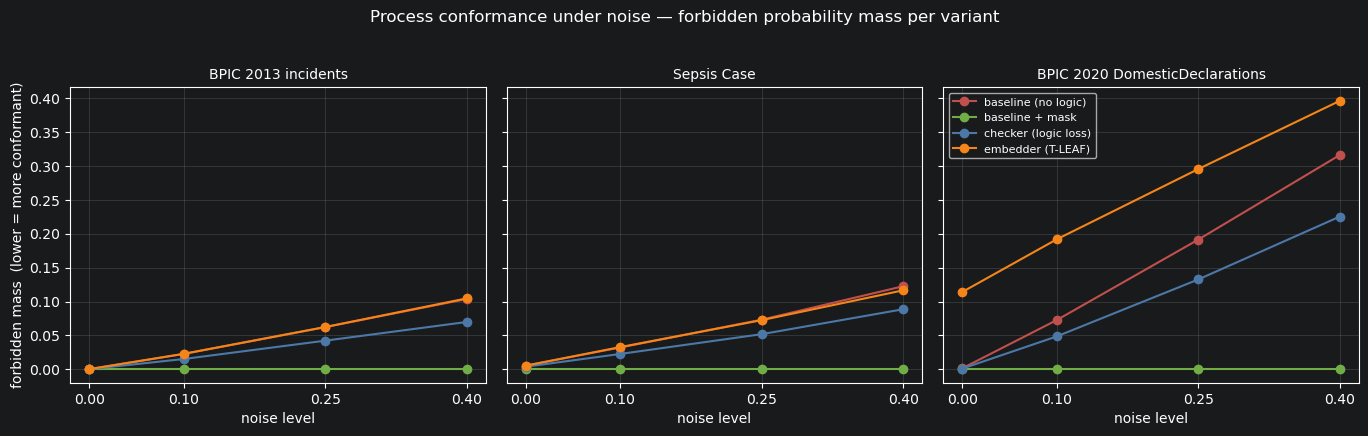

In [5]:
bp.plot_conformance_by_noise(df, metric="forbidden_mass", path=FIG_DIR / "03_forbidden_mass.png");

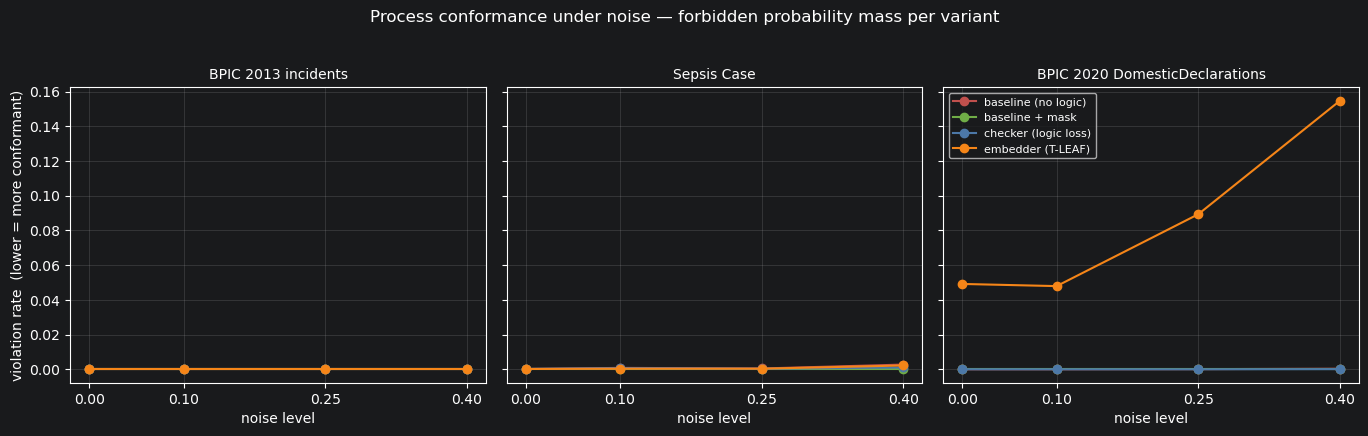

In [6]:
# violation_rate = fraction of predictions that are outright DFA-illegal (argmax-level view).
bp.plot_conformance_by_noise(df, metric="violation_rate", path=FIG_DIR / "03_violation_rate.png");

## 4. Does the logic loss earn its keep? (gain vs. cost)

Conformance is only interesting if it is cheap in accuracy. Averaging over the **noisy** cells,
for each dataset we compare a logic variant against the bare baseline:

- **bars (left axis)** — % reduction in forbidden mass (the *win*);
- **diamonds (right axis)** — accuracy change in percentage points (the *cost*).

The claim holds when bars are large and positive while diamonds hover near 0pp.

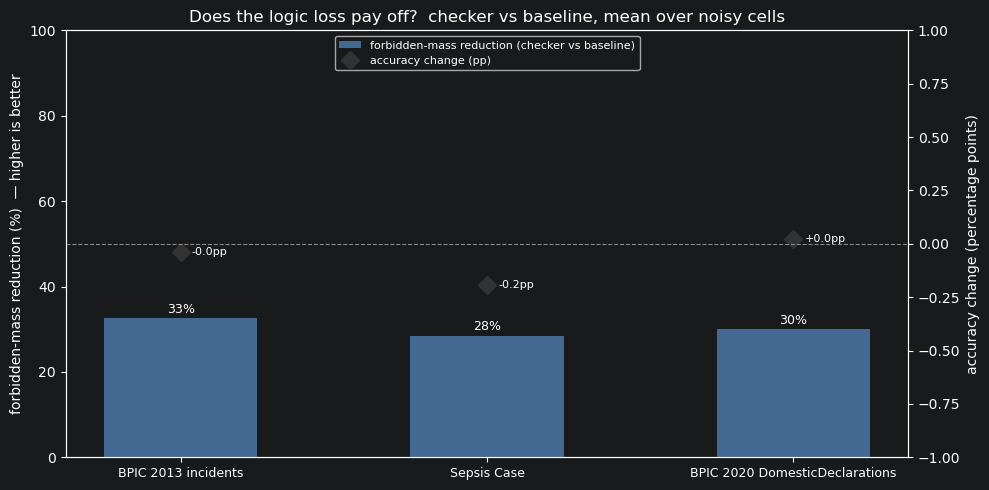

In [7]:
bp.plot_logic_effect(df, treatment="checker", reference="baseline",
                     path=FIG_DIR / "04_logic_effect_checker.png");

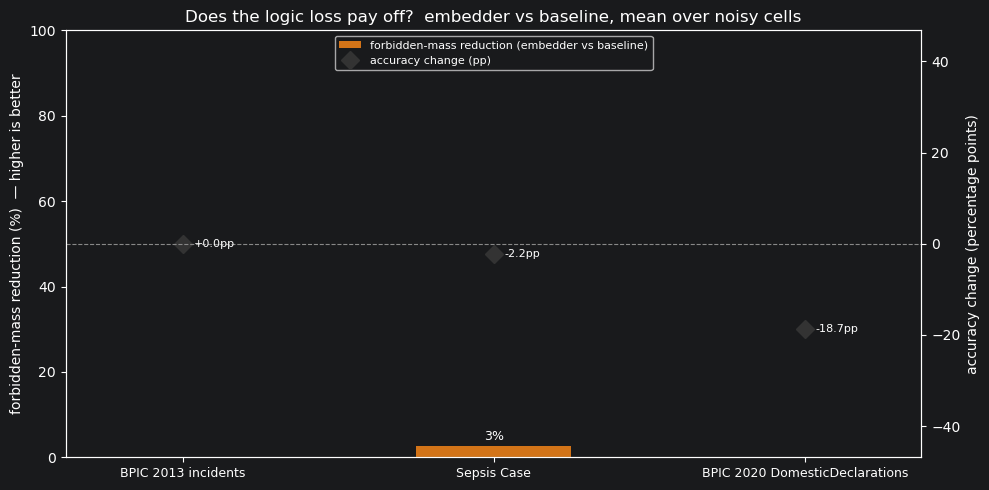

In [8]:
# Embedder branch — only renders if the CSV carries 'embedder' rows.
if "embedder" in df["variant"].unique():
    bp.plot_logic_effect(df, treatment="embedder", reference="baseline",
                         path=FIG_DIR / "04_logic_effect_embedder.png")
else:
    print("No 'embedder' rows in this CSV yet — re-run the grid with the embedder "
          "variant to populate this plot.")

### The whole trade-off at a glance

Every `(dataset, variant, noise)` cell as one point: accuracy on `x`, forbidden mass on `y`,
colour = variant, marker = dataset, **point size grows with noise**. The ideal corner is
**bottom-right** (accurate *and* conformant). Read it as: at matched accuracy, do the logic
variants sit *lower* (more conformant) than the baseline — and do they stay there as the
points grow (noise rises)?

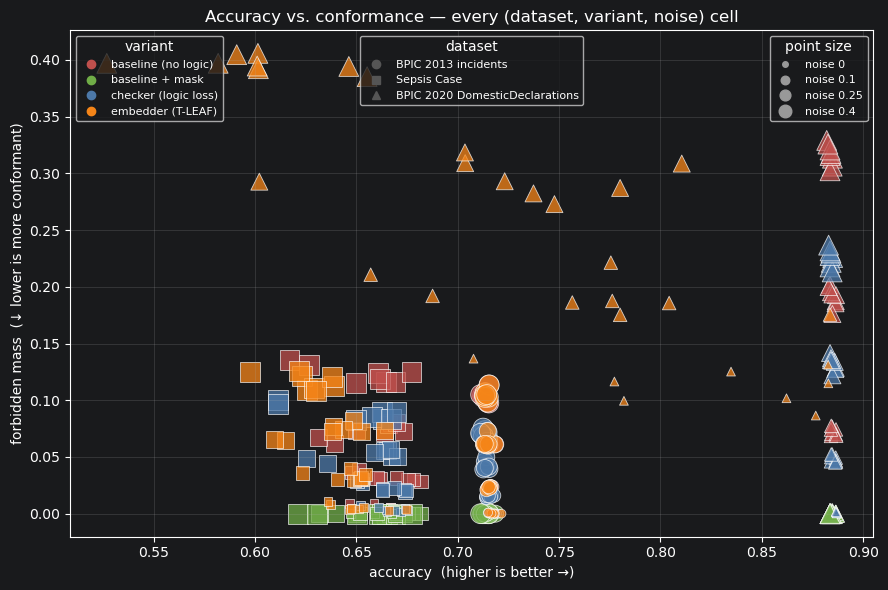

In [9]:
bp.plot_accuracy_conformance_tradeoff(df, path=FIG_DIR / "04_tradeoff_scatter.png");

## 5. What moves together? (correlation)

A Spearman correlation over the benchmark's *design* axes (noise, corrupted count, training
volume, DFA size) and *outcomes* (loss, accuracy, F1, conformance, runtime). Spearman because
several relations are monotone but nonlinear. What to look for:

- `noise_level` ↔ `forbidden_mass` / `loss` strongly **positive** (corruption pushes the model
  off-process and up the loss);
- `noise_level` ↔ `accuracy` mildly **negative**;
- `accuracy` ↔ `macro_f1` strongly positive (sanity);
- `forbidden_mass` largely **decoupled** from `accuracy` — the two axes the thesis trades off.

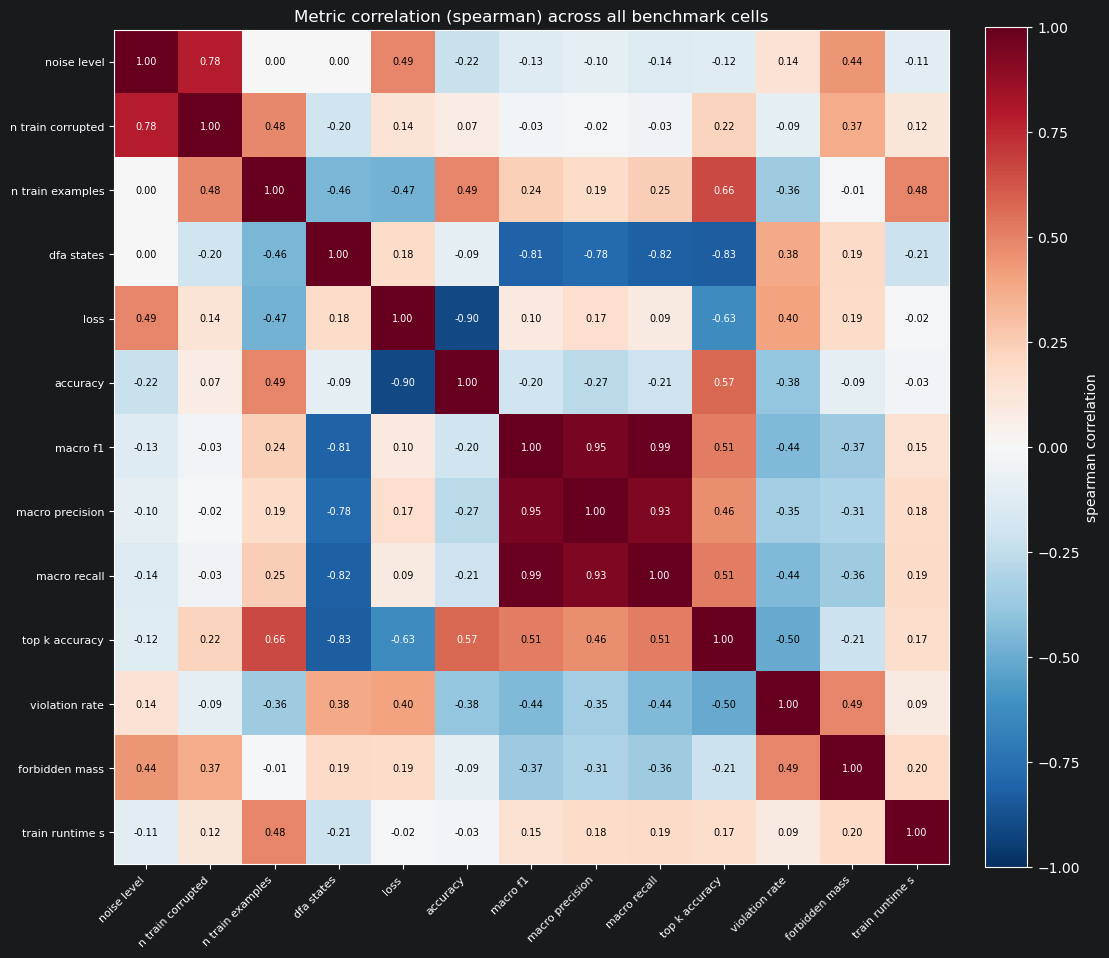

In [10]:
bp.plot_metric_correlation(df, method="spearman", path=FIG_DIR / "05_correlation.png");

## 6. (Optional) Data scarcity

If this CSV was produced with a `train_fraction` sweep, the learning curve below renders;
otherwise it prints a note and skips — the corruption-only file does not vary data volume.

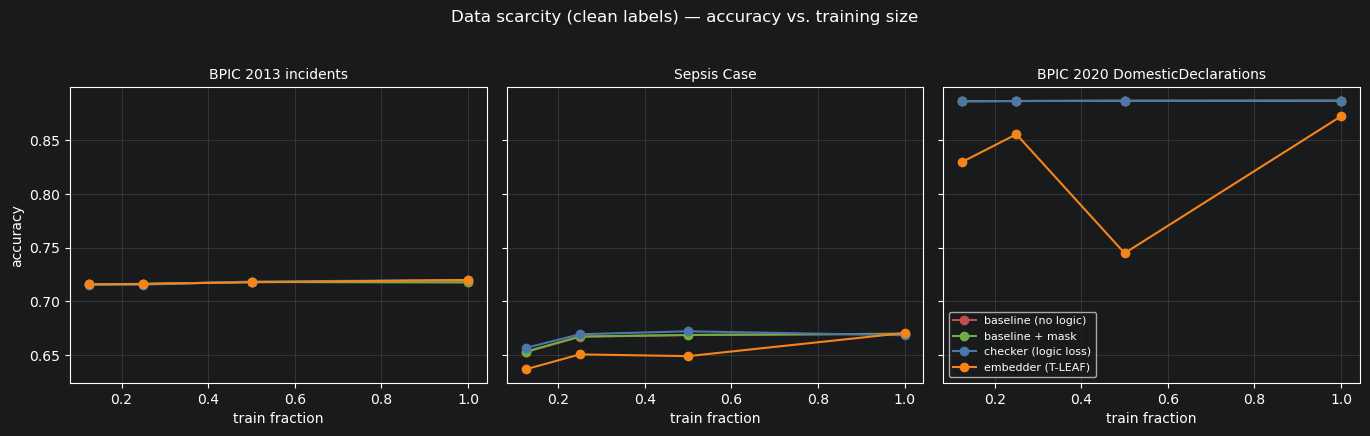

In [11]:
fig = bp.plot_data_scarcity(df, metric="accuracy", path=FIG_DIR / "06_data_scarcity.png")
if fig is None:
    print("This benchmark file has a single training fraction — data-scarcity is reported "
          "by a separate grid (run_corruption_grid(..., train_fractions=[1.0, 0.5, 0.25])).")

## 7. Takeaways

Summarise, per dataset, the headline numbers the figures show: clean-baseline accuracy, and
the conformance picture at the **highest** noise level (how far the baseline drifts vs. how
well `checker` — and `embedder`, if present — hold the line).

In [12]:
worst = df["noise_level"].max()
rows = []
for ds in summary["datasets"]:
    sub = df[df["dataset"] == ds]
    clean_acc = sub[(sub.noise_level == 0) & (sub.variant == "baseline")]["accuracy"].mean()
    hi = sub[sub.noise_level == worst]
    entry = {"dataset": ds, "clean_baseline_acc": round(clean_acc, 3)}
    for v in summary["variants"]:
        fm = hi[hi.variant == v]["forbidden_mass"].mean()
        if pd.notna(fm):
            entry[f"forbidden_mass@{worst:g}::{v}"] = round(fm, 4)
    rows.append(entry)

takeaways = pd.DataFrame(rows).set_index("dataset")
print(f"Conformance at the highest noise level ({worst:g}):")
takeaways

Conformance at the highest noise level (0.4):


,clean_baseline_acc,forbidden_mass@0.4::baseline,forbidden_mass@0.4::baseline_mask,forbidden_mass@0.4::checker,forbidden_mass@0.4::embedder
dataset,,,,,
BPIC_2013_incidents,0.717,0.1038,0.0,0.0699,0.1047
Sepsis_Case,0.664,0.1227,0.0,0.0887,0.1166
BPIC_2020_DomesticDeclarations,0.887,0.3164,0.0,0.2255,0.3964


**Reading the result (single seed — treat deltas qualitatively).**

- The three logs differ sharply in difficulty: BPIC-2020 is near-saturated, Sepsis is the
  hard, imbalanced case where conformance pressure matters most.
- Under noise, the unconstrained `baseline`'s **forbidden mass climbs** with the corruption
  fraction — exactly the failure the symbolic layer is meant to catch.
- `baseline_mask` drives forbidden mass to **0** for free but only post-hoc; `checker`
  (and `embedder`) suppress it during *training*, keeping the model conformant while the loss
  is still differentiable — the property masking can't give you (you can't backprop a hard mask
  into a better-shaped distribution).
- The accuracy cost of the soft logic loss is small (§4), so the conformance is close to free.

> **Caveat (see `docs/IMPROVEMENTS.md` §2.2).** All rows are a **single seed**. Treat the
> conformance *direction* as robust and the precise percentage-point deltas as indicative
> until the multi-seed grid (mean ± std) is run.